# Hydro Balances

In [30]:
# =============================================================================
# (1) FORECAST CURVE IDS
# =============================================================================
FORECAST_CURVE_IDS: dict[str, dict[str, dict[str, int]]] = {
    "NO1": {
        "inflows": {"volue": 802502096},
        "hydrobalance": {
            "volue": 802501549,
            "pointconnect": 103281914,
        },  # OBS: Pointconnect shared across NO areas
        "precip": {"volue": 802501825},
        "run_of_river": {"volue": 802500606},
        "reservoir": {"volue": 1500000280},
        "snowgroundwater": {"volue": 802501559, "pointconnect": 101603655},
    },
    "NO2": {
        "inflows": {"volue": 802502097},
        "hydrobalance": {"volue": 802501550, "pointconnect": 103281914},
        "precip": {"volue": 802501826},
        "run_of_river": {"volue": 802500607},
        "reservoir": {"volue": 1500000281},
        "snowgroundwater": {"volue": 802501560, "pointconnect": 101605014},
    },
    "NO3": {
        "inflows": {"volue": 802502098},
        "hydrobalance": {"volue": 802501551, "pointconnect": 103281914},
        "precip": {"volue": 802501827},
        "run_of_river": {"volue": 802500608},
        "reservoir": {"volue": 1500000282},
        "snowgroundwater": {"volue": 802501561, "pointconnect": 101604683},
    },
    "NO4": {
        "inflows": {"volue": 802502099},
        "hydrobalance": {"volue": 802501552, "pointconnect": 103281914},
        "precip": {"volue": 802501828},
        "run_of_river": {"volue": 802500609},
        "reservoir": {"volue": 1500000283},
        "snowgroundwater": {"volue": 802501562, "pointconnect": 104382103},
    },
    "NO5": {
        "inflows": {"volue": 802502100},
        "hydrobalance": {"volue": 802501553, "pointconnect": 103281914},
        "precip": {"volue": 802501829},
        "run_of_river": {"volue": 802500610},
        "reservoir": {"volue": 1500000284},
        "snowgroundwater": {"volue": 802501563, "pointconnect": 104382134},
    },
    "SE1": {
        "inflows": {"volue": 802502101},
        "hydrobalance": {"volue": 802501554, "pointconnect": 103281910},
        "precip": {"volue": 802501830},
        "run_of_river": {"volue": 802500611},
        "reservoir": {"volue": 1500000285},
        "snowgroundwater": {"volue": 802501564, "pointconnect": 101597596},
    },
    "SE2": {
        "inflows": {"volue": 802502102},
        "hydrobalance": {"volue": 802501555, "pointconnect": 103281910},
        "precip": {"volue": 802501831},
        "run_of_river": {"volue": 802500612},
        "reservoir": {"volue": 1500000286},
        "snowgroundwater": {"volue": 802501565, "pointconnect": 101597449},
    },
    "SE3": {
        "inflows": {"volue": 802502103},
        "hydrobalance": {"volue": 802501556, "pointconnect": 103281910},
        "precip": {"volue": 802501832},
        "run_of_river": {"volue": 802500613},
        "reservoir": {"volue": 1500000287},
        "snowgroundwater": {"volue": 802501566, "pointconnect": 101597824},
    },
    "SE4": {
        "inflows": {"volue": 802502104},
        "hydrobalance": {"volue": 802501557, "pointconnect": 103281910},
        "precip": {"volue": 802501833},
        "run_of_river": {"volue": 802500614},
        "reservoir": {"volue": 1500000288},
        "snowgroundwater": {"volue": 802501567, "pointconnect": 103302628},
    },
    "FIN": {
        "inflows": {"volue": 802502095},
        "hydrobalance": {"volue": 802501558, "pointconnect": 103281918},
        "precip": {"volue": 802501834},
        "run_of_river": {"volue": 802500615},
        "reservoir": {"volue": 1500000289},
        "snowgroundwater": {"volue": 802501568, "pointconnect": 101600108},
    },
    "Nordic": {
        "hydrobalance": {
            "volue": 802500590,
            "pointconnect": 103281922,
        },
        "precip": {"volue": 802501813},
        "snowgroundwater": {"pointconnect": 102418104},
    },
}

hydro_balance_forecasts_ids: dict[str, int] = {
    "NO": 103281914,
    "SE": 103281910,
    "FIN": 103281918,
    "Nordic": 103281922
}


In [31]:
from kad_functions.sql_data import get_sql_query
import pandas as pd

hydro_balances = {}

tommorrow = (pd.Timestamp.now(tz="UTC").normalize() + pd.Timedelta(days=1)).strftime("%Y-%m-%d")

for countrycode in list(hydro_balance_pointconnect_ids.keys()):

    country_query = f"""
        SELECT ValueDateUTC, ForecastDateUTC, Value
        FROM pub.Timeseries1_v02
        WHERE CurveId = {hydro_balance_pointconnect_ids[countrycode]}
        AND IsLatestForecast = 1
        ORDER BY ValueDateUTC ASC
    """

    country_data = get_sql_query(country_query)
    country_data["ValueDateUTC"] = pd.to_datetime(country_data["ValueDateUTC"], utc=True)
    country_data["ForecastDateUTC"] = pd.to_numeric(country_data["ForecastDateUTC"], errors="coerce")
    country_data["CountryCode"] = countrycode

    print(f"Data for {countrycode}:")
    display(country_data)

    hydro_balances[countrycode] = country_data

hydro_balances_df = pd.concat(hydro_balances.values(), ignore_index=True)
print("Combined Hydro Balances DataFrame:")
display(hydro_balances_df)

Data for NO:


,ValueDateUTC,ForecastDateUTC,Value,CountryCode
0,2011-02-22 00:00:00+00:00,1298376000000000000,-30800.087386,NO
1,2011-02-23 00:00:00+00:00,1298462400000000000,-30882.783204,NO
2,2011-02-24 00:00:00+00:00,1298548800000000000,-30778.227031,NO
3,2011-02-25 00:00:00+00:00,1298635200000000000,-30527.379513,NO
4,2011-02-26 00:00:00+00:00,1298678400000000000,-30224.300380,NO
...,...,...,...,...
5930,2027-05-19 00:00:00+00:00,1780272000000000000,-8645.530666,NO
5931,2027-05-20 00:00:00+00:00,1780272000000000000,-8497.293908,NO
5932,2027-05-21 00:00:00+00:00,1780272000000000000,-8321.321777,NO
5933,2027-05-22 00:00:00+00:00,1780272000000000000,-7935.328152,NO


Data for SE:


,ValueDateUTC,ForecastDateUTC,Value,CountryCode
0,2011-02-22 00:00:00+00:00,1298376000000000000,-10987.999344,SE
1,2011-02-23 00:00:00+00:00,1298462400000000000,-11059.175547,SE
2,2011-02-24 00:00:00+00:00,1298548800000000000,-11016.246564,SE
3,2011-02-25 00:00:00+00:00,1298635200000000000,-10951.521553,SE
4,2011-02-26 00:00:00+00:00,1298635200000000000,-10993.816699,SE
...,...,...,...,...
5930,2027-05-19 00:00:00+00:00,1780272000000000000,-2195.261152,SE
5931,2027-05-20 00:00:00+00:00,1780272000000000000,-2250.904995,SE
5932,2027-05-21 00:00:00+00:00,1780272000000000000,-2349.902437,SE
5933,2027-05-22 00:00:00+00:00,1780272000000000000,-2366.211480,SE


Data for FIN:


,ValueDateUTC,ForecastDateUTC,Value,CountryCode
0,2011-02-22 00:00:00+00:00,1298376000000000000,-3333.917403,FIN
1,2011-02-23 00:00:00+00:00,1298462400000000000,-3396.291341,FIN
2,2011-02-24 00:00:00+00:00,1298548800000000000,-3431.783633,FIN
3,2011-02-25 00:00:00+00:00,1298635200000000000,-3457.317208,FIN
4,2011-02-26 00:00:00+00:00,1298678400000000000,-3482.448867,FIN
...,...,...,...,...
5930,2027-05-19 00:00:00+00:00,1780272000000000000,-706.468594,FIN
5931,2027-05-20 00:00:00+00:00,1780272000000000000,-731.092253,FIN
5932,2027-05-21 00:00:00+00:00,1780272000000000000,-754.514911,FIN
5933,2027-05-22 00:00:00+00:00,1780272000000000000,-782.844069,FIN


Data for Nordic:


,ValueDateUTC,ForecastDateUTC,Value,CountryCode
0,2011-02-22 00:00:00+00:00,1298376000000000000,-45122.004132,Nordic
1,2011-02-23 00:00:00+00:00,1298462400000000000,-45338.250092,Nordic
2,2011-02-24 00:00:00+00:00,1298548800000000000,-45226.257228,Nordic
3,2011-02-25 00:00:00+00:00,1298635200000000000,-44936.218274,Nordic
4,2011-02-26 00:00:00+00:00,1298721600000000000,-44700.565947,Nordic
...,...,...,...,...
5930,2027-05-19 00:00:00+00:00,1780272000000000000,-11547.260412,Nordic
5931,2027-05-20 00:00:00+00:00,1780272000000000000,-11479.291155,Nordic
5932,2027-05-21 00:00:00+00:00,1780272000000000000,-11425.739125,Nordic
5933,2027-05-22 00:00:00+00:00,1780272000000000000,-11084.383701,Nordic


Combined Hydro Balances DataFrame:


,ValueDateUTC,ForecastDateUTC,Value,CountryCode
0,2011-02-22 00:00:00+00:00,1298376000000000000,-30800.087386,NO
1,2011-02-23 00:00:00+00:00,1298462400000000000,-30882.783204,NO
2,2011-02-24 00:00:00+00:00,1298548800000000000,-30778.227031,NO
3,2011-02-25 00:00:00+00:00,1298635200000000000,-30527.379513,NO
4,2011-02-26 00:00:00+00:00,1298678400000000000,-30224.300380,NO
...,...,...,...,...
23735,2027-05-19 00:00:00+00:00,1780272000000000000,-11547.260412,Nordic
23736,2027-05-20 00:00:00+00:00,1780272000000000000,-11479.291155,Nordic
23737,2027-05-21 00:00:00+00:00,1780272000000000000,-11425.739125,Nordic
23738,2027-05-22 00:00:00+00:00,1780272000000000000,-11084.383701,Nordic


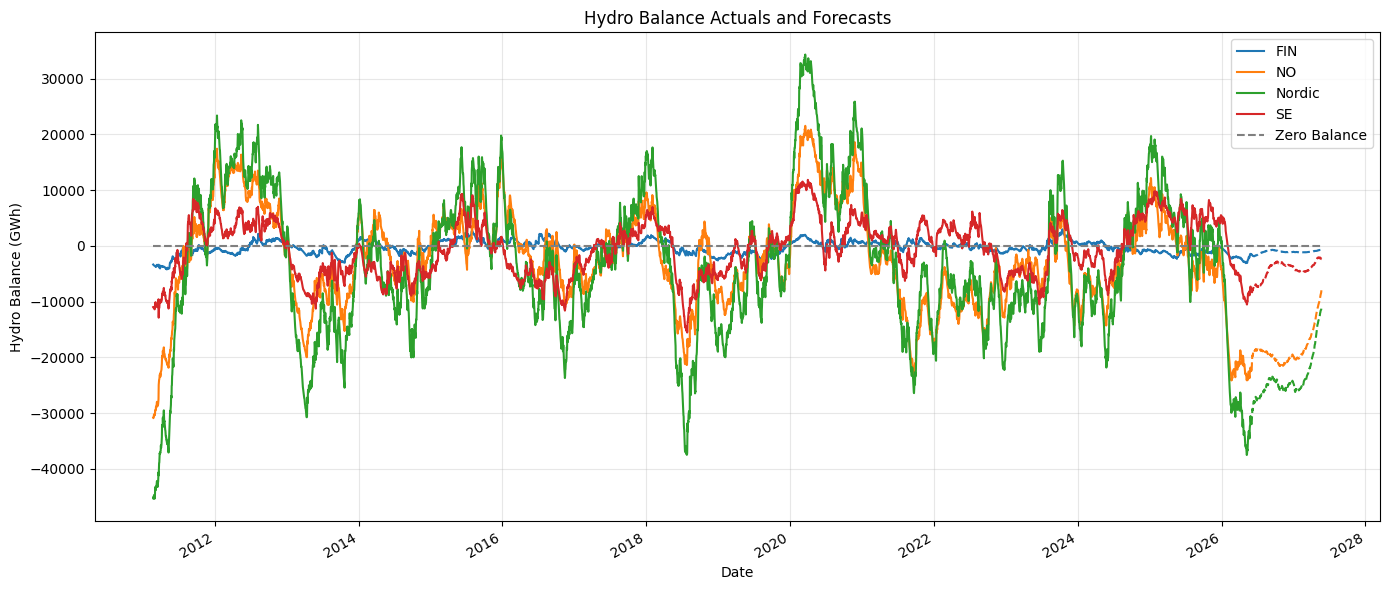

In [33]:
import matplotlib.pyplot as plt

tommorrow = (pd.Timestamp.now(tz="UTC").normalize() + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
actual_data = hydro_balances_df[hydro_balances_df["ValueDateUTC"] < tommorrow]
forecast_data = hydro_balances_df[hydro_balances_df["ValueDateUTC"] >= tommorrow]

fig, ax = plt.subplots(figsize=(14, 6))

for (i, (country, group)) in enumerate(actual_data.groupby("CountryCode")):
    ax.plot(group["ValueDateUTC"], group["Value"], label=country, color=plt.cm.tab10(i % 10))

for (i, (country, group)) in enumerate(forecast_data.groupby("CountryCode")):
    ax.plot(group["ValueDateUTC"], group["Value"], linestyle="dashed", color=plt.cm.tab10(i % 10))

ax.hlines(0, xmin=hydro_balances_df["ValueDateUTC"].min(), xmax=hydro_balances_df["ValueDateUTC"].max(), colors="gray", linestyles="dashed", label="Zero Balance")

ax.set_xlabel("Date")
ax.set_ylabel("Hydro Balance (GWh)")
ax.set_title("Hydro Balance Actuals and Forecasts")
ax.legend()
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()